Creating Lag Variables for Inflation YoY

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("../data/master_dataset.csv")

df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").reset_index(drop=True)

df.head()

,Date,CPI,GDP,Unemployment,RSI,Bank_Rate,FTSE100,Inflation_YoY,Inflation_lag3,Inflation_lag6
0,2001-07-01,73.7,497938.0,5.1,73.9,5.25,5546.899902,1.515152,1.307639,1.061375
1,2001-08-01,73.9,497938.0,5.1,74.1,5.00,5345.000000,1.931034,1.648352,0.692521
2,2001-09-01,74.1,497938.0,5.1,74.5,4.75,4785.600098,1.367989,1.646091,0.968188
3,2001-10-01,73.9,499278.0,5.1,75.0,4.50,5039.700195,1.025290,1.515152,1.307639
4,2001-11-01,73.8,499278.0,5.2,76.0,4.00,5203.600098,0.819672,1.931034,1.648352


In [2]:
df["Inflation_YoY"] = df["CPI"].pct_change(12) * 100
df["Inflation_lag3"] = df["Inflation_YoY"].shift(3)
df["Inflation_lag6"] = df["Inflation_YoY"].shift(6)
df = df.dropna()

print(df.head())

         Date        CPI       GDP  Unemployment   RSI  Bank_Rate  \
18 2003-01-01  75.066667  514031.0           5.1  78.3       4.00   
19 2003-02-01  75.000000  514031.0           5.2  78.4       3.75   
20 2003-03-01  75.300000  514031.0           5.1  78.7       3.75   
21 2003-04-01  75.500000  518802.0           5.0  78.8       3.75   
22 2003-05-01  75.500000  518802.0           4.9  78.8       3.75   

        FTSE100  Inflation_YoY  Inflation_lag3  Inflation_lag6  
18  3567.399902       1.395768        1.420839        1.085482  
19  3655.600098       1.626016        1.490515        0.947226  
20  3684.800049       1.619433        1.621622        0.944669  
21  3880.100098       1.410343        1.395768        1.420839  
22  4048.100098       1.206434        1.626016        1.490515  


In [3]:
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date")
df = df.set_index("Date")

In [4]:
target = "Inflation_YoY"

features = [
    "Unemployment",
    "Bank_Rate",
    "FTSE100",
    "RSI",
    "Inflation_lag3",
    "Inflation_lag6"
]

In [5]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = pd.DataFrame(
    scaler.fit_transform(df[features]),
    columns=features,
    index=df.index
)

In [6]:
y = df[target]

In [7]:
df_scaled = X_scaled.copy()
df_scaled["Inflation_YoY"] = y

print(df_scaled.head())

            Unemployment  Bank_Rate   FTSE100       RSI  Inflation_lag3  \
Date                                                                      
2003-01-01     -0.256023   0.952557 -2.422726 -1.631366       -0.601068   
2003-02-01     -0.185982   0.830677 -2.343010 -1.619697       -0.568614   
2003-03-01     -0.256023   0.830677 -2.316619 -1.584693       -0.507548   
2003-04-01     -0.326065   0.830677 -2.140107 -1.573025       -0.612746   
2003-05-01     -0.396106   0.830677 -1.988268 -1.573025       -0.505501   

            Inflation_lag6  Inflation_YoY  
Date                                       
2003-01-01       -0.749560       1.395768  
2003-02-01       -0.813766       1.626016  
2003-03-01       -0.814953       1.619433  
2003-04-01       -0.593820       1.410343  
2003-05-01       -0.561462       1.206434  


In [8]:
df_scaled.describe()

,Unemployment,Bank_Rate,FTSE100,RSI,Inflation_lag3,Inflation_lag6,Inflation_YoY
count,2.640000e+02,2.640000e+02,2.640000e+02,2.640000e+02,2.640000e+02,2.640000e+02,264.000000
mean,-1.614870e-16,8.074349e-17,-1.076580e-16,1.076580e-16,8.074349e-17,3.364312e-17,2.722545
std,1.001899e+00,1.001899e+00,1.001899e+00,1.001899e+00,1.001899e+00,1.001899e+00,2.147300
min,-1.306647e+00,-9.122073e-01,-2.422726e+00,-1.631366e+00,-1.309395e+00,-1.300051e+00,-0.099900
25%,-8.163556e-01,-7.537633e-01,-6.299189e-01,-8.146000e-01,-5.653947e-01,-5.722994e-01,1.519048
50%,-2.560231e-01,-7.537633e-01,7.597431e-02,-4.878937e-01,-1.939344e-01,-1.878914e-01,2.304673
75%,6.019860e-01,1.196317e+00,8.141783e-01,9.122759e-01,1.847964e-01,1.897187e-01,3.108046
max,2.125390e+00,1.805717e+00,1.923845e+00,2.370786e+00,3.823924e+00,3.818077e+00,10.921053


## Modelling Phase

Train-Test Split

In [9]:
train = df_scaled.loc["2000":"2018"]
test = df_scaled.loc["2019":"2024"]

print("Train shape:", train.shape)
print("Test shape:", test.shape)

Train shape: (192, 7)
Test shape: (72, 7)


### Defining Features and Target

In [10]:
features = [
    "Unemployment",
    "Bank_Rate",
    "FTSE100",
    "RSI",
    "Inflation_lag3",
    "Inflation_lag6"
]

target = "Inflation_YoY"

X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]

Evaluation Function

In [11]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

def evaluate_model(y_true, y_pred, name):

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    print(f"{name} Performance")
    print("MAE:", round(mae,3))
    print("RMSE:", round(rmse,3))
    print("----------------------")

## ARIMA Model

In [12]:
from statsmodels.tsa.arima.model import ARIMA

arima_model = ARIMA(y_train, order=(3,1,1))

arima_fit = arima_model.fit()

print(arima_fit.summary())

C:\Users\prati\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\prati\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\prati\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:          Inflation_YoY   No. Observations:                  192
Model:                 ARIMA(3, 1, 1)   Log Likelihood                 -32.417
Date:                Wed, 03 Jun 2026   AIC                             74.834
Time:                        01:49:22   BIC                             91.095
Sample:                    01-01-2003   HQIC                            81.420
                         - 12-01-2018                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1973      0.344     -0.574      0.566      -0.871       0.476
ar.L2          0.1601      0.062      2.577      0.010       0.038       0.282
ar.L3          0.1858      0.077      2.420      0.0

In [13]:
arima_pred = arima_fit.forecast(steps=len(y_test))

evaluate_model(y_test, arima_pred, "ARIMA")

ARIMA Performance
MAE: 2.621
RMSE: 3.898
----------------------


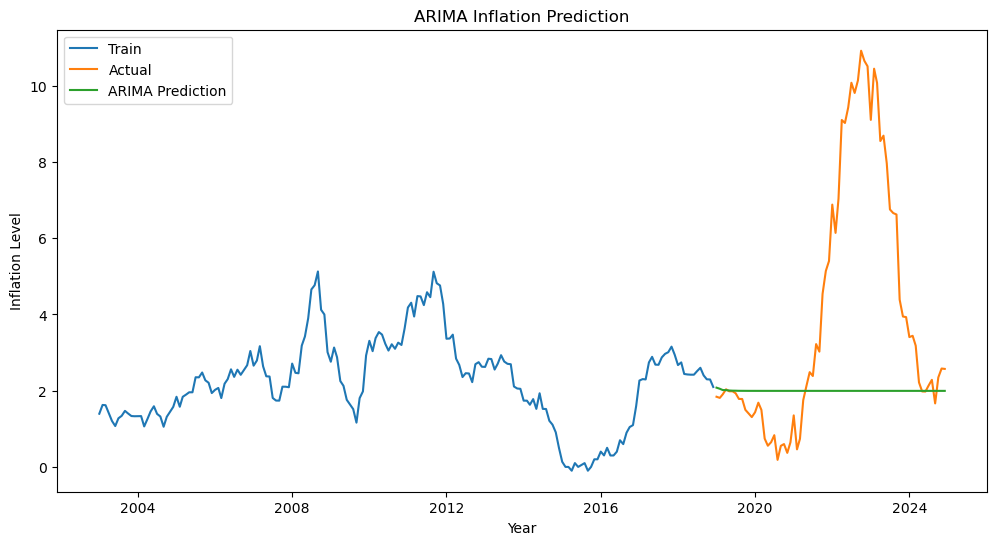

In [14]:
plt.figure(figsize=(12,6))

plt.plot(y_train.index, y_train, label="Train")
plt.plot(y_test.index, y_test, label="Actual")
plt.plot(y_test.index, arima_pred, label="ARIMA Prediction")

# Axis labels
plt.xlabel("Year")
plt.ylabel("Inflation Level")

plt.legend()
plt.title("ARIMA Inflation Prediction")

plt.show()

## Random Forest

In [15]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=8,
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestRegressor(max_depth=8, n_estimators=300, random_state=42)

In [16]:
rf_pred = rf.predict(X_test)

evaluate_model(y_test, rf_pred, "Random Forest")

Random Forest Performance
MAE: 1.971
RMSE: 3.078
----------------------


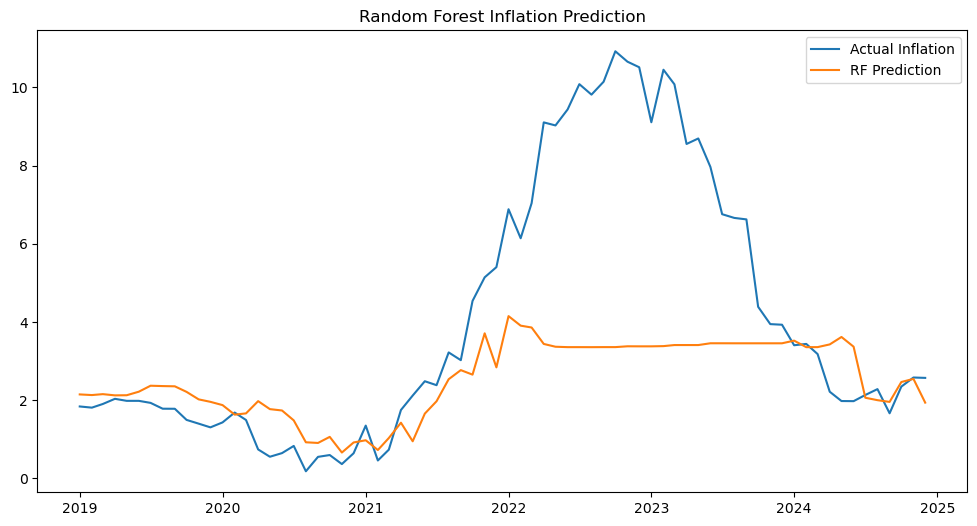

In [17]:
plt.figure(figsize=(12,6))

plt.plot(y_test.index, y_test, label="Actual Inflation")
plt.plot(y_test.index, rf_pred, label="RF Prediction")

plt.legend()
plt.title("Random Forest Inflation Prediction")

plt.show()

## XGBoost

In [18]:
import xgboost as xgb

xgb_model = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, num_parallel_tree=None, ...)

In [19]:
xgb_pred = xgb_model.predict(X_test)

evaluate_model(y_test, xgb_pred, "XGBoost")

XGBoost Performance
MAE: 2.148
RMSE: 3.341
----------------------


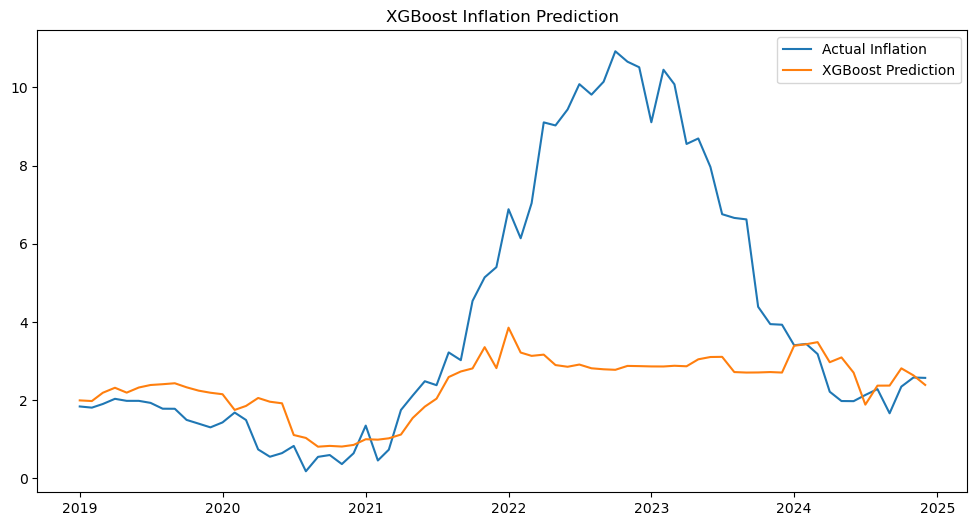

In [20]:
plt.figure(figsize=(12,6))

plt.plot(y_test.index, y_test, label="Actual Inflation")
plt.plot(y_test.index, xgb_pred, label="XGBoost Prediction")

plt.legend()
plt.title("XGBoost Inflation Prediction")

plt.show()

In [21]:
results = pd.DataFrame({
    
    "Model": ["ARIMA","Random Forest","XGBoost"],
    
    "MAE":[
        mean_absolute_error(y_test, arima_pred),
        mean_absolute_error(y_test, rf_pred),
        mean_absolute_error(y_test, xgb_pred)
    ],
    
    "RMSE":[
        np.sqrt(mean_squared_error(y_test, arima_pred)),
        np.sqrt(mean_squared_error(y_test, rf_pred)),
        np.sqrt(mean_squared_error(y_test, xgb_pred))
    ]
})

results

,Model,MAE,RMSE
0,ARIMA,2.621390,3.898419
1,Random Forest,1.970662,3.078246
2,XGBoost,2.147507,3.340706


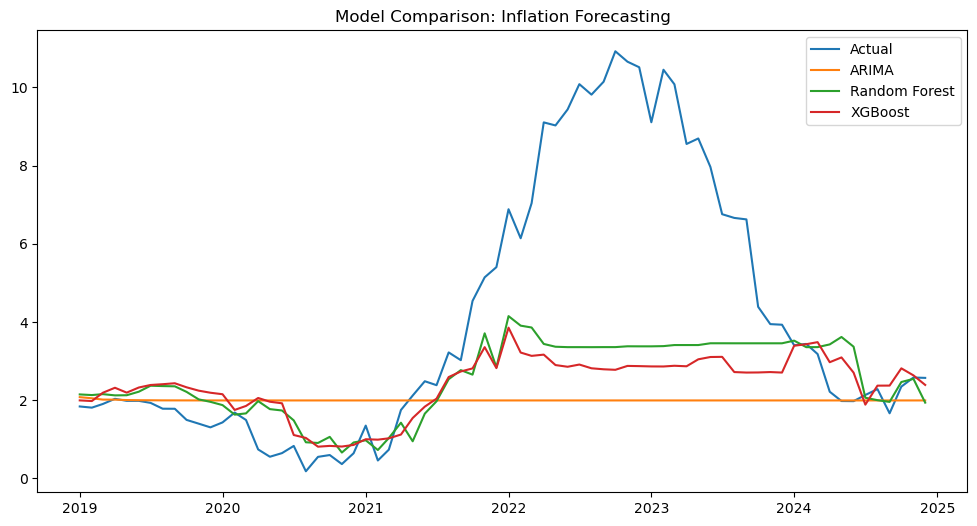

In [22]:
plt.figure(figsize=(12,6))

plt.plot(y_test.index, y_test, label="Actual")

plt.plot(y_test.index, arima_pred, label="ARIMA")
plt.plot(y_test.index, rf_pred, label="Random Forest")
plt.plot(y_test.index, xgb_pred, label="XGBoost")

plt.legend()
plt.title("Model Comparison: Inflation Forecasting")

plt.show()

# Model Improvement

In [23]:
df_model = df.copy()

Adding improved features

In [24]:
# Inflation lags

df_model["Inflation_lag1"] = df_model["Inflation_YoY"].shift(1)
df_model["Inflation_lag2"] = df_model["Inflation_YoY"].shift(2)
df_model["Inflation_lag3"] = df_model["Inflation_YoY"].shift(3)
df_model["Inflation_lag6"] = df_model["Inflation_YoY"].shift(6)
df_model["Inflation_lag12"] = df_model["Inflation_YoY"].shift(12)

# Macroeconomic changes

df_model["GDP_growth"] = df_model["GDP"].pct_change()
df_model["FTSE_returns"] = df_model["FTSE100"].pct_change()
df_model["Unemployment_change"] = df_model["Unemployment"].diff()
df_model["RSI_change"] = df_model["RSI"].diff()

df_model = df_model.dropna()

In [25]:
df_model["Inflation_momentum_3"] = df_model["Inflation_YoY"] - df_model["Inflation_lag3"]

df_model["Inflation_momentum_6"] = df_model["Inflation_YoY"] - df_model["Inflation_lag6"]

In [26]:
df_model["Rate_Unemployment"] = df_model["Bank_Rate"] * df_model["Unemployment"]

df_model["Market_Sentiment"] = df_model["FTSE_returns"] * df_model["RSI_change"]

In [27]:
df_model = df_model.dropna()

In [28]:
target = "Inflation_YoY"

features = [
    "GDP",
    "Unemployment",
    "Unemployment_change",

    "Bank_Rate",

    "FTSE100",
    "FTSE_returns",

    "RSI",
    "RSI_change",

    "Inflation_lag1",
    "Inflation_lag2",
    "Inflation_lag3",
    "Inflation_lag6",
    "Inflation_lag12",

    "Inflation_momentum_3",
    "Inflation_momentum_6",

    "Rate_Unemployment",
    "Market_Sentiment",
    
    "GDP_growth"
]

In [29]:
## Z-score Scaling

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = pd.DataFrame(
    scaler.fit_transform(df_model[features]),
    columns=features,
    index=df_model.index
)

df_model_scaled = X_scaled.copy()
df_model_scaled["Inflation_YoY"] = df_model["Inflation_YoY"]

In [30]:
## Train-Test Split

train = df_model_scaled.loc["2000":"2018"]
test = df_model_scaled.loc["2019":"2024"]

X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]

### Improved Random forest

In [31]:
rf_improved = RandomForestRegressor(

    n_estimators=800,
    max_depth=14,
    min_samples_split=4,
    random_state=42
)

rf_improved.fit(X_train, y_train)

rf_pred_improved = rf_improved.predict(X_test)

In [32]:
final_scaler = scaler
final_model = rf_improved
final_features = features.copy()

In [33]:
final_rmse = 2.648897

In [34]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

rf_mae = mean_absolute_error(y_test, rf_pred_improved)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred_improved))

print("Improved Random Forest")
print("MAE:", rf_mae)
print("RMSE:", rf_rmse)

Improved Random Forest
MAE: 1.5418231844443906
RMSE: 2.589421279982676


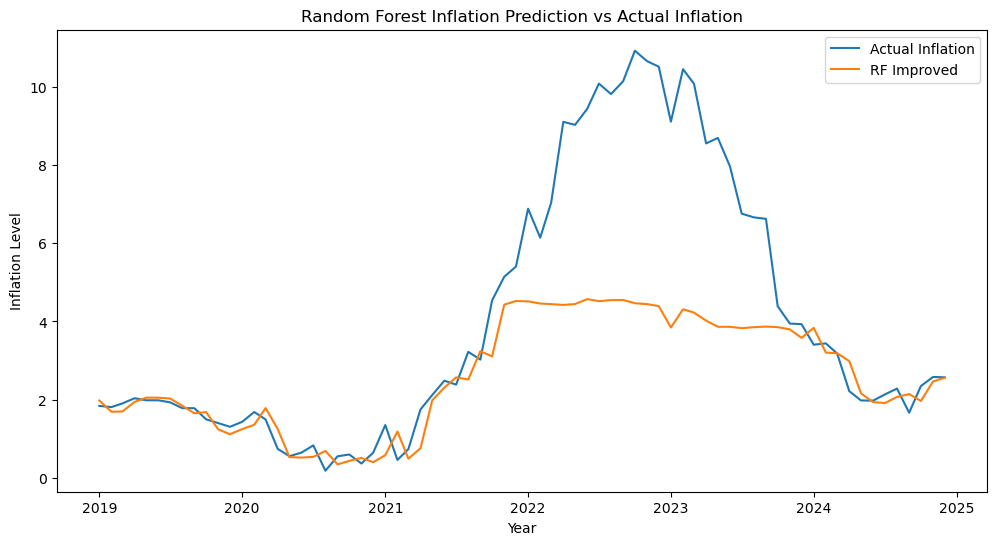

In [35]:
plt.figure(figsize=(12,6))

plt.plot(y_test.index, y_test, label="Actual Inflation")
plt.plot(y_test.index, rf_pred_improved, label="RF Improved")

# Axis labels
plt.xlabel("Year")
plt.ylabel("Inflation Level")

plt.legend()
plt.title("Random Forest Inflation Prediction vs Actual Inflation")

plt.show()

### Improved XGBoost

In [36]:
import xgboost as xgb

xgb_improved = xgb.XGBRegressor(

    n_estimators=900,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_improved.fit(X_train, y_train)

xgb_pred_improved = xgb_improved.predict(X_test)

In [37]:
xgb_mae = mean_absolute_error(y_test, xgb_pred_improved)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred_improved))

print("Improved XGBoost")
print("MAE:", xgb_mae)
print("RMSE:", xgb_rmse)

Improved XGBoost
MAE: 1.612339022577859
RMSE: 2.6980294113118037


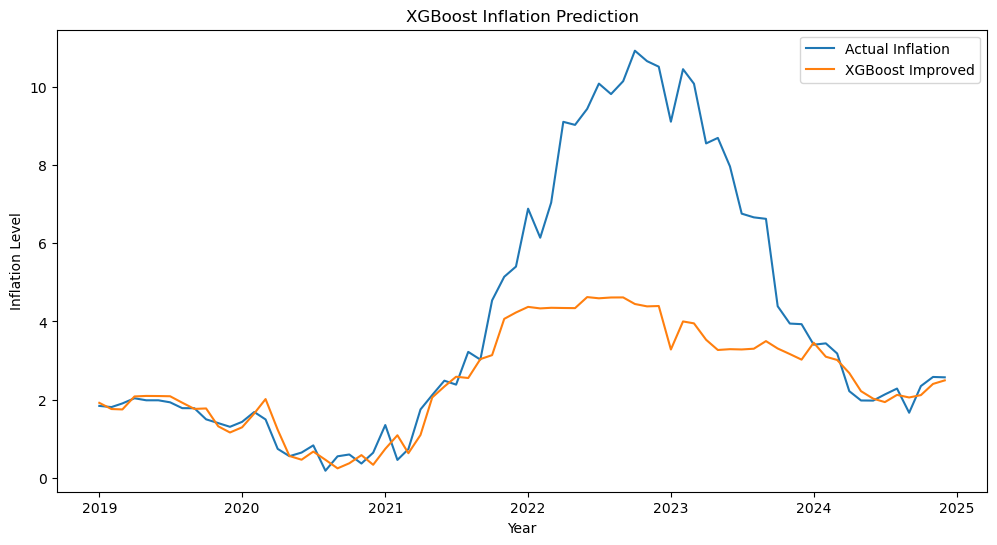

In [38]:
plt.figure(figsize=(12,6))

plt.plot(y_test.index, y_test, label="Actual Inflation")
plt.plot(y_test.index, xgb_pred_improved, label="XGBoost Improved")

# Axis labels
plt.xlabel("Year")
plt.ylabel("Inflation Level")

plt.legend()
plt.title("XGBoost Inflation Prediction")

plt.show()

In [39]:
comparison = pd.DataFrame({

    "Model":[
        "Random Forest (Baseline)",
        "Random Forest (Improved)",
        "XGBoost (Baseline)",
        "XGBoost (Improved)"
    ],

    "RMSE":[
        3.080073,
        rf_rmse,
        3.388367,
        xgb_rmse
    ]
})

comparison

,Model,RMSE
0,Random Forest (Baseline),3.080073
1,Random Forest (Improved),2.589421
2,XGBoost (Baseline),3.388367
3,XGBoost (Improved),2.698029


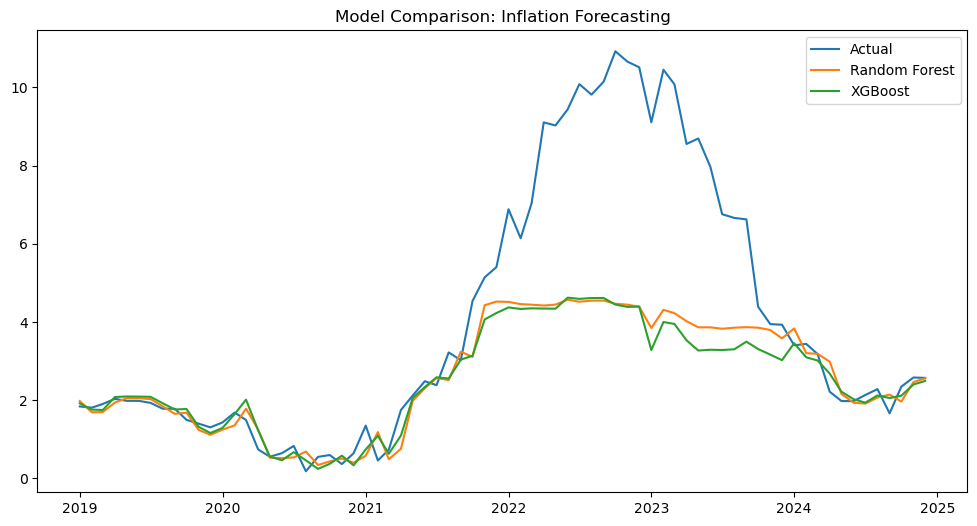

In [40]:
plt.figure(figsize=(12,6))

plt.plot(y_test.index, y_test, label="Actual")

#plt.plot(y_test.index, arima_pred, label="ARIMA")
plt.plot(y_test.index, rf_pred_improved, label="Random Forest")
plt.plot(y_test.index, xgb_pred_improved, label="XGBoost")

plt.legend()
plt.title("Model Comparison: Inflation Forecasting")

plt.show()

# Walk-Forward Validation

In [41]:
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)

rmse_scores = []

for train_index, test_index in tscv.split(df_model):

    train = df_model.iloc[train_index]
    test = df_model.iloc[test_index]

    X_train = train[features]
    y_train = train[target]

    X_test = test[features]
    y_test = test[target]

    rf = RandomForestRegressor(n_estimators=600, random_state=42)

    rf.fit(X_train, y_train)

    preds = rf.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, preds))

    rmse_scores.append(rmse)

print("Walk Forward RMSE:", np.mean(rmse_scores))

Walk Forward RMSE: 1.2007296043904563


In [42]:
print(df.head())
print(df_model.head())

                  CPI       GDP  Unemployment   RSI  Bank_Rate      FTSE100  \
Date                                                                          
2003-01-01  75.066667  514031.0           5.1  78.3       4.00  3567.399902   
2003-02-01  75.000000  514031.0           5.2  78.4       3.75  3655.600098   
2003-03-01  75.300000  514031.0           5.1  78.7       3.75  3684.800049   
2003-04-01  75.500000  518802.0           5.0  78.8       3.75  3880.100098   
2003-05-01  75.500000  518802.0           4.9  78.8       3.75  4048.100098   

            Inflation_YoY  Inflation_lag3  Inflation_lag6  
Date                                                       
2003-01-01       1.395768        1.420839        1.085482  
2003-02-01       1.626016        1.490515        0.947226  
2003-03-01       1.619433        1.621622        0.944669  
2003-04-01       1.410343        1.395768        1.420839  
2003-05-01       1.206434        1.626016        1.490515  
                  CPI     

# Validation + Visualization

Final modelling dataset shape: (252, 19)
Date range: 2004-01-01 00:00:00 to 2024-12-01 00:00:00

Previous holdout split
Train: 2004-01-01 00:00:00 to 2018-12-01 00:00:00 | (180, 19)
Test : 2019-01-01 00:00:00 to 2022-12-01 00:00:00 | (48, 19)

Previous holdout results
                        Dataset          Model       MAE      RMSE        R2
0  Previous Holdout (2019-2022)  Random Forest  1.411083  2.486526  0.481345
1  Previous Holdout (2019-2022)        XGBoost  1.408338  2.493684  0.478354

New validation split
Train: 2004-01-01 00:00:00 to 2022-12-01 00:00:00 | (228, 19)
Test : 2023-01-01 00:00:00 to 2024-12-01 00:00:00 | (24, 19)

New validation results
                      Dataset          Model       MAE      RMSE        R2
0  New Validation (2023-2024)  Random Forest  2.545499  2.752260  0.080982
1  New Validation (2023-2024)        XGBoost  2.870175  3.122957 -0.183252

Combined performance comparison
                        Dataset          Model       MAE      RMSE       

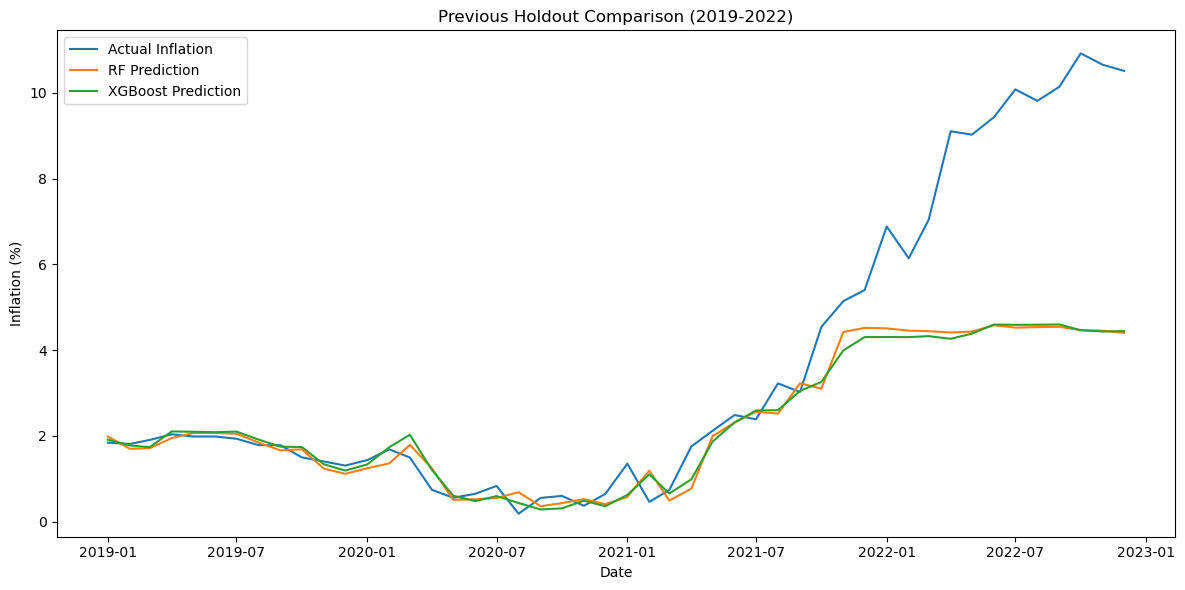

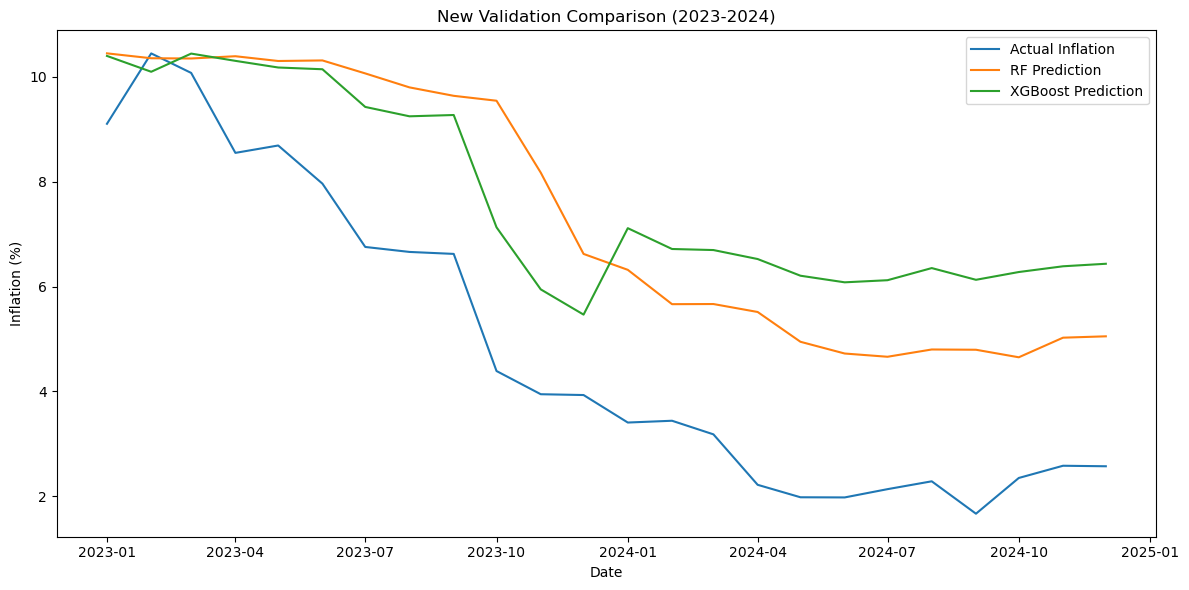

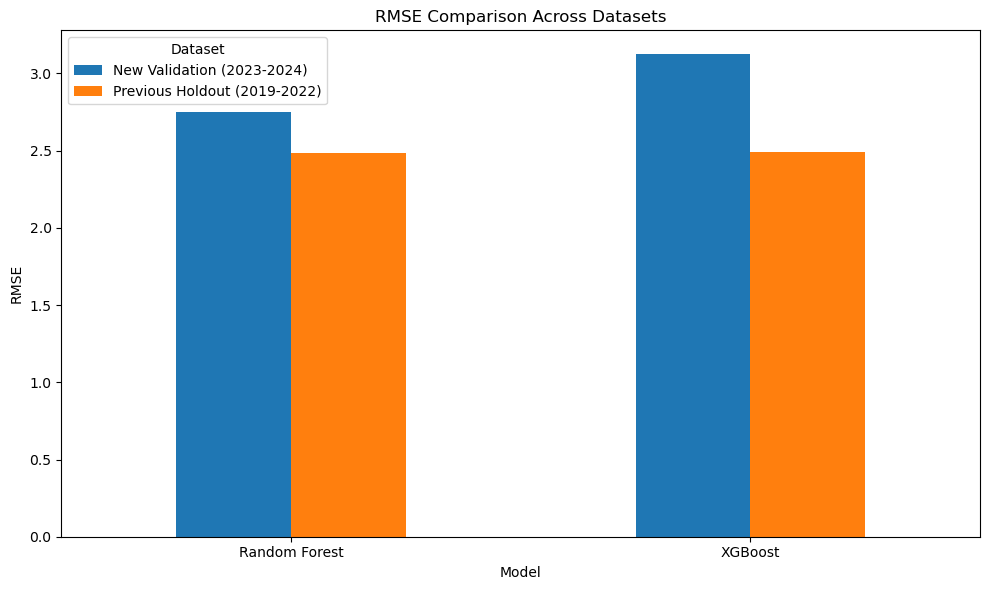

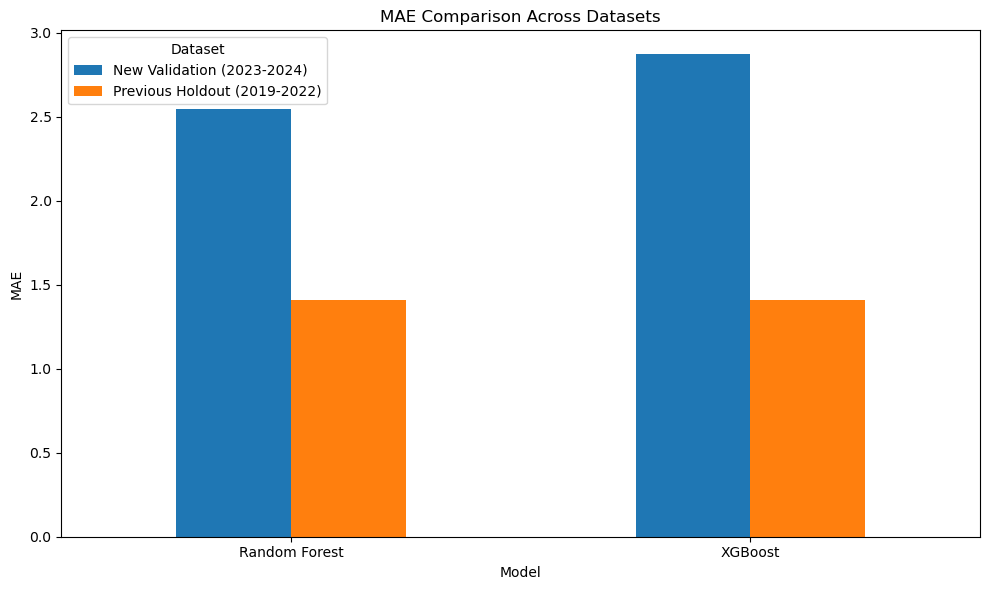

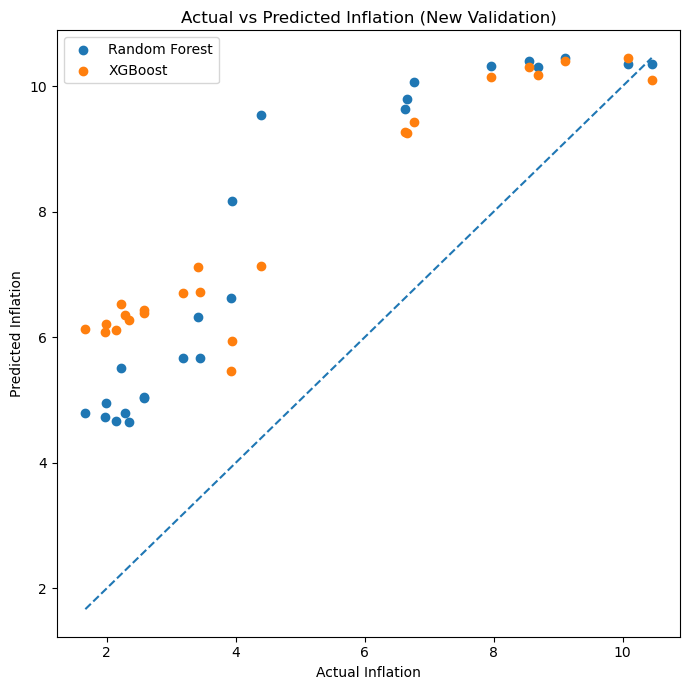

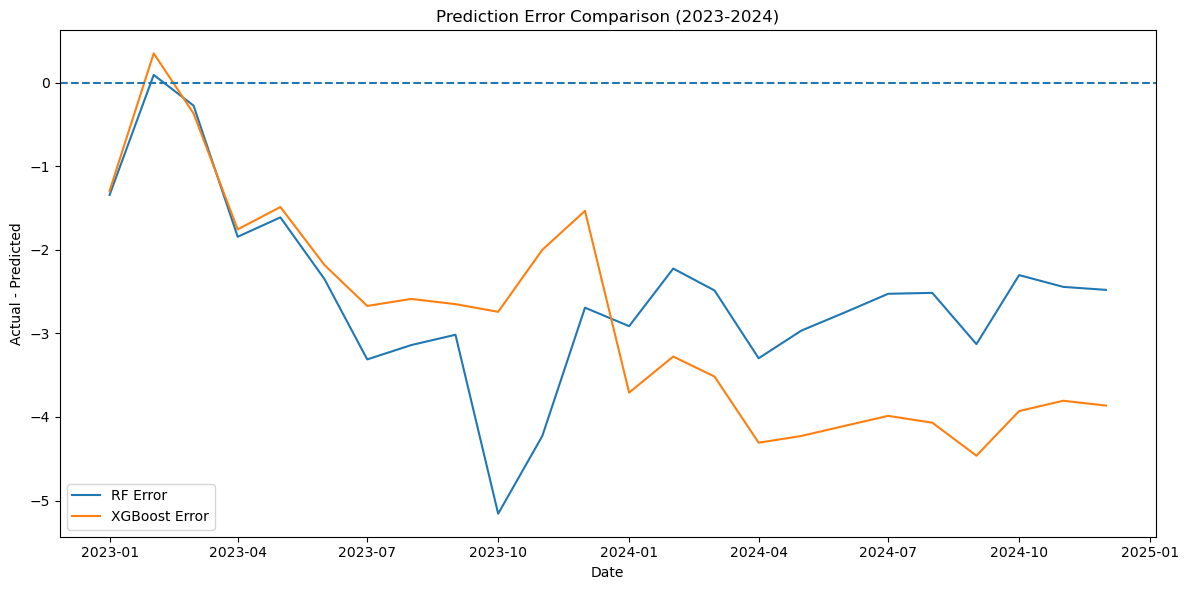


Best model on new validation dataset:
Dataset    New Validation (2023-2024)
Model                   Random Forest
MAE                          2.545499
RMSE                          2.75226
R2                           0.080982
Name: 0, dtype: object


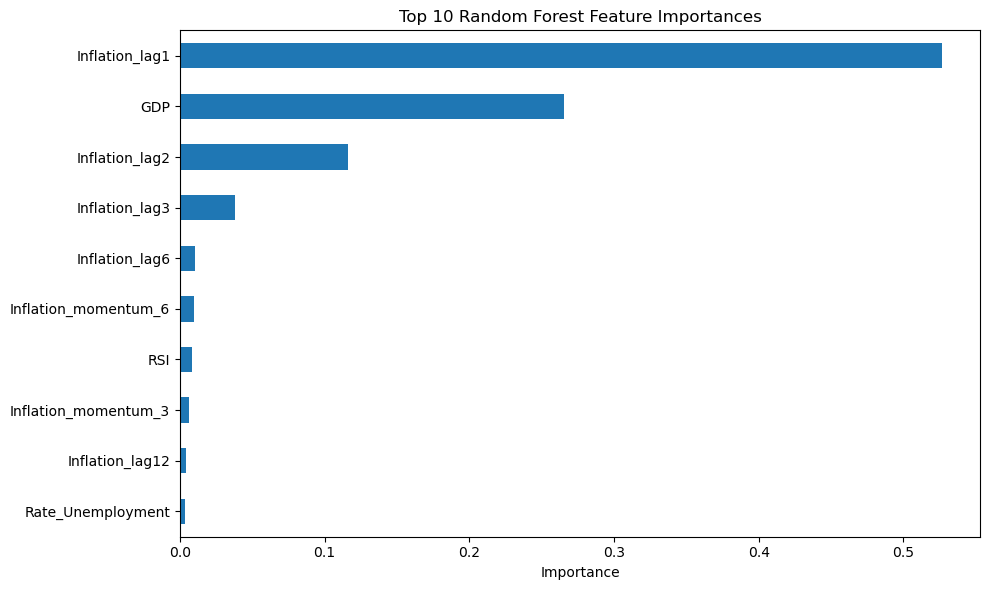

In [43]:


from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb

historical_df_source = df_model.copy()

required_cols = ["Inflation_YoY", "GDP", "Unemployment", "Bank_Rate", "FTSE100", "RSI"]
missing_cols = [col for col in required_cols if col not in historical_df_source.columns]

if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")

final_df = historical_df_source.copy()
final_df.index = pd.to_datetime(final_df.index)
final_df = final_df.sort_index()

final_df.index = final_df.index.to_period("M").to_timestamp(how="start")
final_df = final_df[~final_df.index.duplicated(keep="last")]

if "Inflation_lag1" not in final_df.columns:
    final_df["Inflation_lag1"] = final_df["Inflation_YoY"].shift(1)
if "Inflation_lag2" not in final_df.columns:
    final_df["Inflation_lag2"] = final_df["Inflation_YoY"].shift(2)
if "Inflation_lag3" not in final_df.columns:
    final_df["Inflation_lag3"] = final_df["Inflation_YoY"].shift(3)
if "Inflation_lag6" not in final_df.columns:
    final_df["Inflation_lag6"] = final_df["Inflation_YoY"].shift(6)
if "Inflation_lag12" not in final_df.columns:
    final_df["Inflation_lag12"] = final_df["Inflation_YoY"].shift(12)

if "GDP_growth" not in final_df.columns:
    final_df["GDP_growth"] = final_df["GDP"].pct_change()
if "FTSE_returns" not in final_df.columns:
    final_df["FTSE_returns"] = final_df["FTSE100"].pct_change()
if "Unemployment_change" not in final_df.columns:
    final_df["Unemployment_change"] = final_df["Unemployment"].diff()
if "RSI_change" not in final_df.columns:
    final_df["RSI_change"] = final_df["RSI"].diff()

if "Inflation_momentum_3" not in final_df.columns:
    final_df["Inflation_momentum_3"] = final_df["Inflation_YoY"] - final_df["Inflation_lag3"]
if "Inflation_momentum_6" not in final_df.columns:
    final_df["Inflation_momentum_6"] = final_df["Inflation_YoY"] - final_df["Inflation_lag6"]

if "Rate_Unemployment" not in final_df.columns:
    final_df["Rate_Unemployment"] = final_df["Bank_Rate"] * final_df["Unemployment"]
if "Market_Sentiment" not in final_df.columns:
    final_df["Market_Sentiment"] = final_df["FTSE_returns"].fillna(0) + final_df["RSI_change"].fillna(0)

target = "Inflation_YoY"

features = [
    "Unemployment",
    "Unemployment_change",
    "Bank_Rate",
    "GDP",
    "GDP_growth",
    "FTSE100",
    "FTSE_returns",
    "RSI",
    "RSI_change",
    "Inflation_lag1",
    "Inflation_lag2",
    "Inflation_lag3",
    "Inflation_lag6",
    "Inflation_lag12",
    "Inflation_momentum_3",
    "Inflation_momentum_6",
    "Rate_Unemployment",
    "Market_Sentiment"
]

final_df = final_df[[target] + features].dropna().copy()

print("Final modelling dataset shape:", final_df.shape)
print("Date range:", final_df.index.min(), "to", final_df.index.max())

rf_final = RandomForestRegressor(
    n_estimators=1200,
    max_depth=20,
    min_samples_split=3,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

xgb_final = xgb.XGBRegressor(
    n_estimators=2000,
    learning_rate=0.01,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42
)

models = {
    "Random Forest": rf_final,
    "XGBoost": xgb_final
}

def evaluate_predictions(y_true, y_pred, model_name, dataset_name):
    return pd.DataFrame({
        "Dataset": [dataset_name],
        "Model": [model_name],
        "MAE": [mean_absolute_error(y_true, y_pred)],
        "RMSE": [np.sqrt(mean_squared_error(y_true, y_pred))],
        "R2": [r2_score(y_true, y_pred)]
    })

def train_and_predict(model, train_df, test_df, features, target):
    X_train = train_df[features]
    y_train = train_df[target]
    X_test = test_df[features]
    y_test = test_df[target]

    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    return pd.DataFrame({
        "Actual": y_test,
        "Predicted": preds
    }, index=y_test.index)


train_old = final_df.loc[: "2018-12-01"].copy()
test_old = final_df.loc["2019-01-01":"2022-12-01"].copy()

if train_old.empty or test_old.empty:
    raise ValueError("Previous holdout split is empty. Check the date range in final_df.")

print("\nPrevious holdout split")
print("Train:", train_old.index.min(), "to", train_old.index.max(), "|", train_old.shape)
print("Test :", test_old.index.min(), "to", test_old.index.max(), "|", test_old.shape)

results_old = []
predictions_old = {}

for model_name, model in models.items():
    pred_df = train_and_predict(model, train_old, test_old, features, target)
    predictions_old[model_name] = pred_df
    results_old.append(
        evaluate_predictions(
            pred_df["Actual"],
            pred_df["Predicted"],
            model_name,
            "Previous Holdout (2019-2022)"
        )
    )

results_old = pd.concat(results_old, ignore_index=True)
print("\nPrevious holdout results")
print(results_old)


train_new = final_df.loc[: "2022-12-01"].copy()
test_new = final_df.loc["2023-01-01":"2024-12-01"].copy()

if train_new.empty or test_new.empty:
    raise ValueError("New validation split is empty. Check the date range in final_df.")

print("\nNew validation split")
print("Train:", train_new.index.min(), "to", train_new.index.max(), "|", train_new.shape)
print("Test :", test_new.index.min(), "to", test_new.index.max(), "|", test_new.shape)

results_new = []
predictions_new = {}

for model_name, model in models.items():
    pred_df = train_and_predict(model, train_new, test_new, features, target)
    predictions_new[model_name] = pred_df
    results_new.append(
        evaluate_predictions(
            pred_df["Actual"],
            pred_df["Predicted"],
            model_name,
            "New Validation (2023-2024)"
        )
    )

results_new = pd.concat(results_new, ignore_index=True)
print("\nNew validation results")
print(results_new)


results_compare = pd.concat([results_old, results_new], ignore_index=True)

print("\nCombined performance comparison")
print(results_compare)

results_compare.to_csv("model_validation_comparison.csv", index=False)
print("\nSaved as model_validation_comparison.csv")

plt.figure(figsize=(12, 6))
plt.plot(test_old.index, test_old[target], label="Actual Inflation")
plt.plot(predictions_old["Random Forest"].index,
         predictions_old["Random Forest"]["Predicted"],
         label="RF Prediction")
plt.plot(predictions_old["XGBoost"].index,
         predictions_old["XGBoost"]["Predicted"],
         label="XGBoost Prediction")
plt.title("Previous Holdout Comparison (2019-2022)")
plt.xlabel("Date")
plt.ylabel("Inflation (%)")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(test_new.index, test_new[target], label="Actual Inflation")
plt.plot(predictions_new["Random Forest"].index,
         predictions_new["Random Forest"]["Predicted"],
         label="RF Prediction")
plt.plot(predictions_new["XGBoost"].index,
         predictions_new["XGBoost"]["Predicted"],
         label="XGBoost Prediction")
plt.title("New Validation Comparison (2023-2024)")
plt.xlabel("Date")
plt.ylabel("Inflation (%)")
plt.legend()
plt.tight_layout()
plt.show()

pivot_rmse = results_compare.pivot(index="Model", columns="Dataset", values="RMSE")
pivot_rmse.plot(kind="bar", figsize=(10, 6))
plt.title("RMSE Comparison Across Datasets")
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

pivot_mae = results_compare.pivot(index="Model", columns="Dataset", values="MAE")
pivot_mae.plot(kind="bar", figsize=(10, 6))
plt.title("MAE Comparison Across Datasets")
plt.xlabel("Model")
plt.ylabel("MAE")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 7))
plt.scatter(predictions_new["Random Forest"]["Actual"],
            predictions_new["Random Forest"]["Predicted"],
            label="Random Forest")
plt.scatter(predictions_new["XGBoost"]["Actual"],
            predictions_new["XGBoost"]["Predicted"],
            label="XGBoost")

min_val = min(
    predictions_new["Random Forest"]["Actual"].min(),
    predictions_new["Random Forest"]["Predicted"].min(),
    predictions_new["XGBoost"]["Predicted"].min()
)
max_val = max(
    predictions_new["Random Forest"]["Actual"].max(),
    predictions_new["Random Forest"]["Predicted"].max(),
    predictions_new["XGBoost"]["Predicted"].max()
)

plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")
plt.title("Actual vs Predicted Inflation (New Validation)")
plt.xlabel("Actual Inflation")
plt.ylabel("Predicted Inflation")
plt.legend()
plt.tight_layout()
plt.show()

error_df = pd.DataFrame(index=test_new.index)
error_df["RF_Error"] = (
    predictions_new["Random Forest"]["Actual"] -
    predictions_new["Random Forest"]["Predicted"]
)
error_df["XGB_Error"] = (
    predictions_new["XGBoost"]["Actual"] -
    predictions_new["XGBoost"]["Predicted"]
)

plt.figure(figsize=(12, 6))
plt.plot(error_df.index, error_df["RF_Error"], label="RF Error")
plt.plot(error_df.index, error_df["XGB_Error"], label="XGBoost Error")
plt.axhline(0, linestyle="--")
plt.title("Prediction Error Comparison (2023-2024)")
plt.xlabel("Date")
plt.ylabel("Actual - Predicted")
plt.legend()
plt.tight_layout()
plt.show()


best_model_row = results_new.sort_values("RMSE").iloc[0]

print("\nBest model on new validation dataset:")
print(best_model_row)

rf_final.fit(train_new[features], train_new[target])
rf_importance = pd.Series(
    rf_final.feature_importances_,
    index=features
).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
rf_importance.head(10).sort_values().plot(kind="barh")
plt.title("Top 10 Random Forest Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


R² Comparison Table:
           Model  Standard R²  Improved R² (vs Naive)
0  Random Forest     0.080982               -12.08750
1        XGBoost    -0.183252               -15.89758


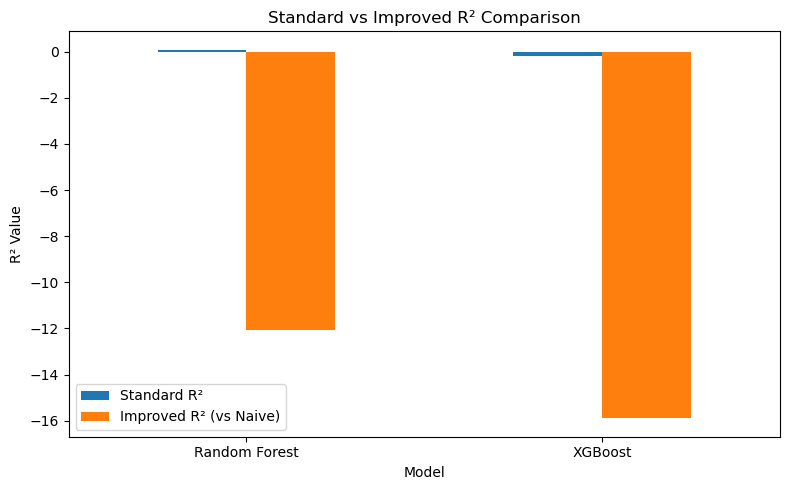

In [44]:
from sklearn.metrics import r2_score

rf_actual = predictions_new["Random Forest"]["Actual"]
rf_pred = predictions_new["Random Forest"]["Predicted"]

xgb_actual = predictions_new["XGBoost"]["Actual"]
xgb_pred = predictions_new["XGBoost"]["Predicted"]


rf_r2_standard = r2_score(rf_actual, rf_pred)
xgb_r2_standard = r2_score(xgb_actual, xgb_pred)


rf_naive = rf_actual.shift(1).dropna()
xgb_naive = xgb_actual.shift(1).dropna()

rf_actual_aligned = rf_actual.iloc[1:]
rf_pred_aligned = rf_pred.iloc[1:]

xgb_actual_aligned = xgb_actual.iloc[1:]
xgb_pred_aligned = xgb_pred.iloc[1:]


rf_skill_r2 = 1 - (
    np.sum((rf_actual_aligned - rf_pred_aligned) ** 2) /
    np.sum((rf_actual_aligned - rf_naive) ** 2)
)

xgb_skill_r2 = 1 - (
    np.sum((xgb_actual_aligned - xgb_pred_aligned) ** 2) /
    np.sum((xgb_actual_aligned - xgb_naive) ** 2)
)

r2_results = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost"],
    "Standard R²": [rf_r2_standard, xgb_r2_standard],
    "Improved R² (vs Naive)": [rf_skill_r2, xgb_skill_r2]
})

print("\nR² Comparison Table:")
print(r2_results)

r2_results.set_index("Model").plot(kind="bar", figsize=(8,5))

plt.title("Standard vs Improved R² Comparison")
plt.ylabel("R² Value")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [45]:
# ALTERNATIVE VALIDATION SPLIT (2020–2024)
train_alt = final_df.loc[: "2019-12-01"].copy()
test_alt = final_df.loc["2020-01-01":"2024-12-01"].copy()

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

# RANDOM FOREST
rf_final.fit(train_alt[features], train_alt[target])
rf_pred_alt = rf_final.predict(test_alt[features])

rf_r2_alt = r2_score(test_alt[target], rf_pred_alt)
rf_rmse_alt = np.sqrt(mean_squared_error(test_alt[target], rf_pred_alt))
rf_mae_alt = mean_absolute_error(test_alt[target], rf_pred_alt)

# XGBOOST
xgb_final.fit(train_alt[features], train_alt[target])
xgb_pred_alt = xgb_final.predict(test_alt[features])

xgb_r2_alt = r2_score(test_alt[target], xgb_pred_alt)
xgb_rmse_alt = np.sqrt(mean_squared_error(test_alt[target], xgb_pred_alt))
xgb_mae_alt = mean_absolute_error(test_alt[target], xgb_pred_alt)

# FINAL OUTPUT
print("Alternative Split (2020–2024)\n")

print("Random Forest")
print("R2:", round(rf_r2_alt, 3))
print("RMSE:", round(rf_rmse_alt, 2))
print("MAE:", round(rf_mae_alt, 2))

print("\nXGBoost")
print("R2:", round(xgb_r2_alt, 3))
print("RMSE:", round(xgb_rmse_alt, 2))
print("MAE:", round(xgb_mae_alt, 2))

Alternative Split (2020–2024)

Random Forest
R2: 0.325
RMSE: 2.85
MAE: 1.83

XGBoost
R2: 0.28
RMSE: 2.94
MAE: 1.9


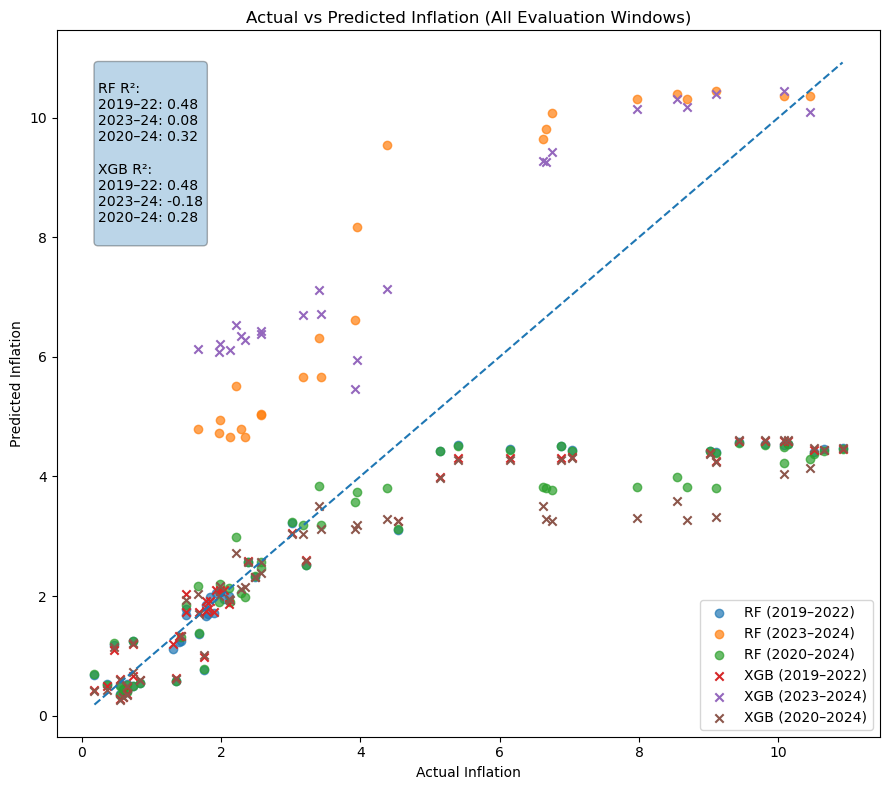

In [46]:
# MULTI-WINDOW SCATTER PLOT

# 2019–2022
rf_old = predictions_old["Random Forest"]
xgb_old = predictions_old["XGBoost"]

# 2023–2024
rf_new = predictions_new["Random Forest"]
xgb_new = predictions_new["XGBoost"]

# 2020–2024 (alternative)
rf_pred_alt_series = pd.Series(rf_pred_alt, index=test_alt.index)
xgb_pred_alt_series = pd.Series(xgb_pred_alt, index=test_alt.index)

rf_r2_old = r2_score(rf_old["Actual"], rf_old["Predicted"])
xgb_r2_old = r2_score(xgb_old["Actual"], xgb_old["Predicted"])

rf_r2_new = r2_score(rf_new["Actual"], rf_new["Predicted"])
xgb_r2_new = r2_score(xgb_new["Actual"], xgb_new["Predicted"])

rf_r2_alt = r2_score(test_alt[target], rf_pred_alt_series)
xgb_r2_alt = r2_score(test_alt[target], xgb_pred_alt_series)

plt.figure(figsize=(9, 8))

plt.scatter(rf_old["Actual"], rf_old["Predicted"], label="RF (2019–2022)", alpha=0.7)
plt.scatter(rf_new["Actual"], rf_new["Predicted"], label="RF (2023–2024)", alpha=0.7)
plt.scatter(test_alt[target], rf_pred_alt_series, label="RF (2020–2024)", alpha=0.7)

plt.scatter(xgb_old["Actual"], xgb_old["Predicted"], label="XGB (2019–2022)", marker='x')
plt.scatter(xgb_new["Actual"], xgb_new["Predicted"], label="XGB (2023–2024)", marker='x')
plt.scatter(test_alt[target], xgb_pred_alt_series, label="XGB (2020–2024)", marker='x')

min_val = min(test_alt[target].min(), rf_old["Actual"].min())
max_val = max(test_alt[target].max(), rf_old["Actual"].max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

textstr = f"""
RF R²:
2019–22: {rf_r2_old:.2f}
2023–24: {rf_r2_new:.2f}
2020–24: {rf_r2_alt:.2f}

XGB R²:
2019–22: {xgb_r2_old:.2f}
2023–24: {xgb_r2_new:.2f}
2020–24: {xgb_r2_alt:.2f}
"""

plt.gca().text(
    0.05, 0.95,
    textstr,
    transform=plt.gca().transAxes,
    fontsize=10,
    verticalalignment='top',
    bbox=dict(boxstyle="round", alpha=0.3)
)

plt.title("Actual vs Predicted Inflation (All Evaluation Windows)")
plt.xlabel("Actual Inflation")
plt.ylabel("Predicted Inflation")
plt.legend()
plt.tight_layout()
plt.show()

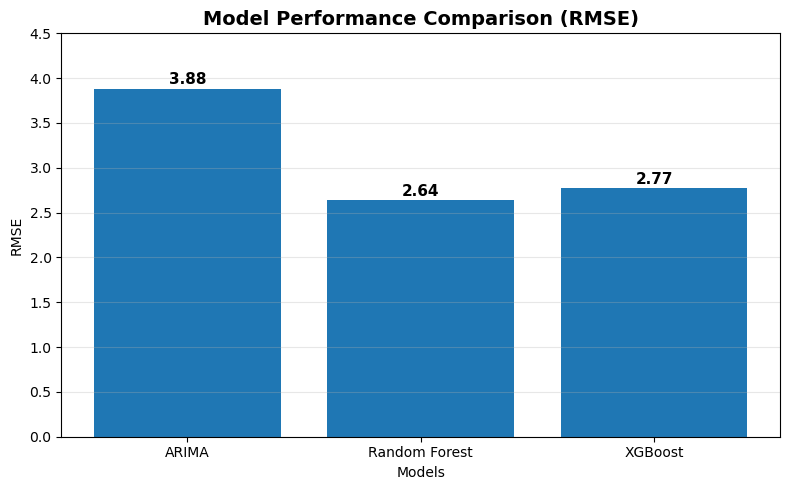

In [47]:
models = ["ARIMA", "Random Forest", "XGBoost"]
rmse_values = [3.88, 2.64, 2.77]

plt.figure(figsize=(8, 5))

bars = plt.bar(models, rmse_values)

for bar, value in zip(bars, rmse_values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.05,
        f"{value:.2f}",
        ha="center",
        fontsize=11,
        fontweight="bold"
    )

plt.title("Model Performance Comparison (RMSE)", fontsize=14, fontweight="bold")
plt.xlabel("Models")
plt.ylabel("RMSE")
plt.ylim(0, 4.5)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()